In [1]:
import zipfile

# Extract knee dataset
with zipfile.ZipFile('/content/knee_data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/knee_data')

# Extract clinical data
with zipfile.ZipFile('/content/clinical_data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/clinical_data')

print("Both datasets extracted successfully!")

Both datasets extracted successfully!


In [2]:
import os

print("Knee Data:", os.listdir('/content/knee_data'))

Knee Data: ['knee_data']


In [8]:
print(os.listdir('/content/knee_data/knee_data/'))

['val', 'train', 'test', 'auto_test']


In [41]:
print("Clinical Data:", os.listdir('/content/clinical_data/clinical_data'))

Clinical Data: ['clinical.xlsx']


In [42]:
base_path = "/content/knee_data/knee_data"

train_dir = base_path + "/train"
val_dir = base_path + "/val"
test_dir = base_path + "/test"

In [43]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 16

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

Found 5778 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.


In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(5, activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    steps_per_epoch=100 // BATCH_SIZE,
    validation_steps=50 // BATCH_SIZE
)

Epoch 1/3
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.3646 - loss: 13.0408 - val_accuracy: 0.1458 - val_loss: 4.8341
Epoch 2/3
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3021 - loss: 2.3082 - val_accuracy: 0.4792 - val_loss: 1.5710
Epoch 3/3
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3333 - loss: 1.5906 - val_accuracy: 0.4167 - val_loss: 1.5065


In [46]:
import numpy as np

sample_img, _ = next(test_data)

pred = cnn.predict(sample_img)

kl_grade = np.argmax(pred[0])

print("KL Grade:", kl_grade)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step
KL Grade: 0


In [23]:
import pandas as pd

df = pd.read_excel(
    "/content/clinical_data/clinical_data/clinical.xlsx",
    nrows=100   # 🔥 only 100 rows
)

print(df.head())

   PatientID    State     Sex GeneralHealth   AgeCategory  HeightInMeters  \
0          1  Alabama  Female          Fair  Age 75 to 79            1.63   
1          2  Alabama  Female     Very good  Age 65 to 69            1.60   
2          3  Alabama    Male     Excellent  Age 60 to 64            1.78   
3          4  Alabama    Male     Very good  Age 70 to 74            1.78   
4          5  Alabama  Female          Good  Age 50 to 54            1.68   

   WeightInKilograms        BMI  HadHeartAttack  HadAngina  ...  \
0          84.820000  32.099998               0          1  ...   
1          71.669998  27.990000               0          0  ...   
2          71.209999  22.530001               0          0  ...   
3          95.250000  30.129999               0          0  ...   
4          78.019997  27.760000               0          0  ...   

                             ECigaretteUsage  ChestScan  \
0  Never used e-cigarettes in my entire life          1   
1  Never used e-

In [24]:
df = df.drop(['PatientID'], axis=1)

In [25]:
df = df.replace({
    'Female': 1,
    'Male': 0
})

/tmp/ipykernel_7442/36891867.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({


In [26]:
df['Sex'] = df['Sex'].map({
    'Female': 1,
    'Male': 0
})

In [30]:
df['AgeCategory'] = df['AgeCategory'].astype(str)
df['AgeCategory'] = df['AgeCategory'].str.extract(r'(\d+)')
df['AgeCategory'] = pd.to_numeric(df['AgeCategory'], errors='coerce')

In [31]:
df = pd.get_dummies(df, drop_first=True)
df = df.fillna(0)

In [32]:
def assign_risk(row):
    if float(row['BMI']) > 30:
        return 2   # High
    elif float(row['BMI']) > 25:
        return 1   # Medium
    else:
        return 0   # Low

df['Risk'] = df.apply(assign_risk, axis=1)

In [33]:
from sklearn.model_selection import train_test_split

X = df.drop('Risk', axis=1)
y = df['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
!pip install xgboost

In [35]:
from xgboost import XGBClassifier

model = XGBClassifier()

model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [36]:
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [37]:
sample = X_test.iloc[0:1]

prediction = model.predict(sample)

print("Predicted Risk:", prediction)

Predicted Risk: [2]


In [38]:
!pip install shap

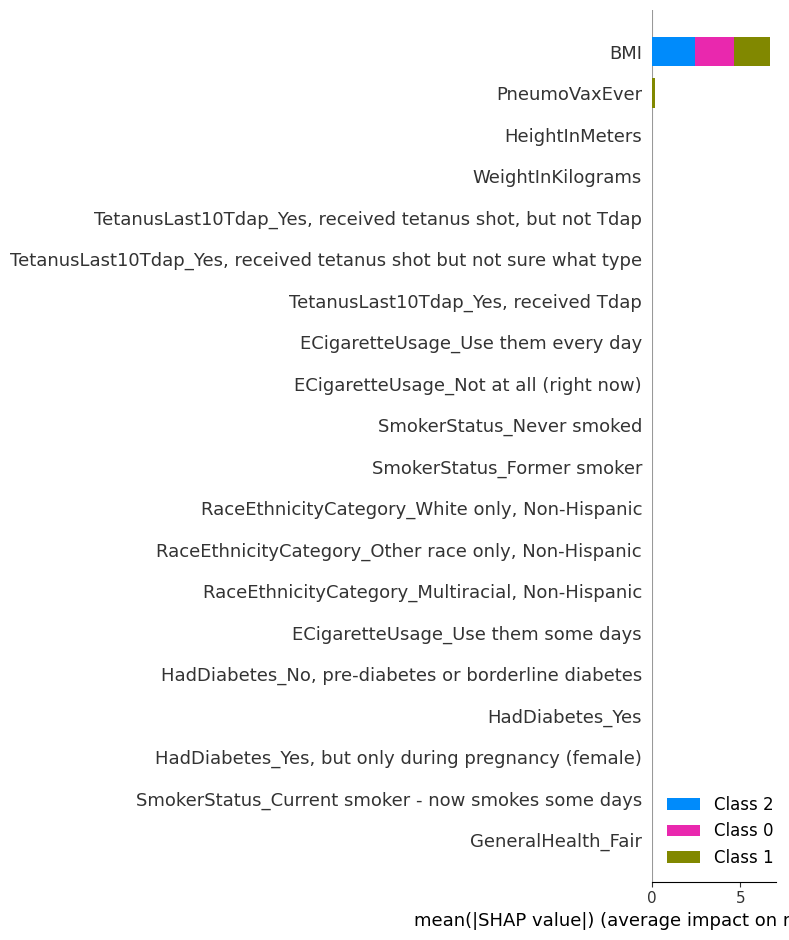

In [39]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [47]:
if kl_grade >= 3 and prediction == 2:
    final_risk = "HIGH"
elif kl_grade == 2:
    final_risk = "MEDIUM"
else:
    final_risk = "LOW"

print("Final Risk:", final_risk)

Final Risk: LOW
